# Exploratory Data Analysis (EDA) Project
## Weekly U.S. Gasoline Product Supplied (Fiscal Years 2020–2026)

**Objective:** Perform an in-depth Exploratory Data Analysis on a real-world weekly
production dataset to uncover patterns, trends, seasonality, and year-over-year
relationships, following the InternsElite Minor Project (EDA) guidelines.

**Dataset:** Weekly volume (in gallons) of finished motor gasoline supplied to the
U.S. market, compiled by the U.S. DOT Federal Highway Administration (Office of
Highway Policy Information) from U.S. Energy Information Administration (EIA)
weekly petroleum supply data. Each row is one fiscal week and reports that week's
production, the same week a year earlier, the week-over-week-year difference, and
running cumulative totals for the fiscal year.

**Tools & Libraries:** Python, Pandas, NumPy, Matplotlib, Seaborn (Jupyter Notebook / Google Colab)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

## 1. Data Import

The raw export is loaded exactly as downloaded — numbers arrive as quoted text
(with thousands separators), so no dtype is inferred correctly yet. That gets
fixed in the cleaning section below.

In [3]:
raw = pd.read_csv("export.csv")

print("Shape:", raw.shape)
print("\nColumns:", list(raw.columns))
print("\nData types before cleaning:")
print(raw.dtypes)
print("\nFirst 5 rows:")
print(raw.head())

Shape: (356, 7)

Columns: ['Fiscal Year', 'Fiscal Week', 'Current Year Production', 'Previous Year Production', 'Difference From Same Week Last Year', 'Current Year Cumulative Production', 'Cumulative Difference']

Data types before cleaning:
Fiscal Year                            int64
Fiscal Week                            int64
Current Year Production                  str
Previous Year Production                 str
Difference From Same Week Last Year      str
Current Year Cumulative Production       str
Cumulative Difference                    str
dtype: object

First 5 rows:
   Fiscal Year  ...  Cumulative Difference
0         2026  ...           -264,600,000
1         2026  ...           -377,496,000
2         2026  ...           -446,586,000
3         2026  ...           -433,062,000
4         2026  ...           -537,432,000

[5 rows x 7 columns]


## 2. Data Cleaning

Steps performed:
1. Rename columns to clear, snake_case names.
2. Remove Excel's stray leading apostrophe (`'`) that was force-marking some
   negative numbers as text, then strip thousands-separator commas and convert
   everything to numeric.
3. Investigate and handle missing/null values (found two distinct issues — see below).
4. Check for and remove duplicate rows.

In [5]:
df = raw.rename(columns={
    "Fiscal Year": "fiscal_year",
    "Fiscal Week": "fiscal_week",
    "Current Year Production": "current_year_gallons",
    "Previous Year Production": "previous_year_gallons",
    "Difference From Same Week Last Year": "yoy_diff_gallons",
    "Current Year Cumulative Production": "cum_current_year_gallons",
    "Cumulative Difference": "cum_diff_gallons",
})

numeric_cols = ["current_year_gallons", "previous_year_gallons", "yoy_diff_gallons",
                "cum_current_year_gallons", "cum_diff_gallons"]

def clean_number(value):
    # Convert a raw text cell like "'-305172000" or "2,485,770,000" to float.
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value.upper() in ("N/A", "NA", ""):
        return np.nan
    value = value.lstrip("'")          # Excel "force text" marker on negatives
    value = value.replace(",", "")     # thousands separators
    return float(value)

for col in numeric_cols:
    df[col] = df[col].apply(clean_number)

print("Data types after cleaning:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Data types after cleaning:
fiscal_year                   int64
fiscal_week                   int64
current_year_gallons        float64
previous_year_gallons       float64
yoy_diff_gallons            float64
cum_current_year_gallons    float64
cum_diff_gallons            float64
dtype: object

Missing values per column:
fiscal_year                 0
fiscal_week                 0
current_year_gallons        0
previous_year_gallons       0
yoy_diff_gallons            1
cum_current_year_gallons    0
cum_diff_gallons            0
dtype: int64


### 2a. Missing-value investigation

Two distinct issues surfaced, and each needed a different fix rather than a
blanket `dropna()` / `fillna()`:

**Issue A — FY2022, Fiscal Week 53.** Most fiscal years only have 52 weeks, but
FY2022 has a 53rd "leap" week. Since FY2021 had no week 53 to compare against,
the source data recorded `Previous Year Production = 0` and
`Difference From Same Week Last Year = N/A`. A production value of 0 gallons is
not real (gasoline was still being supplied that week) — it simply means *no
comparable prior-year week exists*. Recording 0 would corrupt any year-over-year
comparison, so both fields are set to `NaN` for that row instead.

**Issue B — FY2025, Fiscal Week 11 is missing entirely** (not null — the whole
row is absent, confirmed by checking which week numbers exist per fiscal year).
Rather than guessing this value, it can be **recovered exactly**: the running
cumulative-production column is continuous even though the flat weekly row was
dropped, so
`week11_production = cum_through_week12 − cum_through_week10 − week12_production`.
This reconstructs the true reported number (verified against the untouched
cumulative series) instead of an approximation like linear interpolation.

In [7]:
# --- Issue A: FY2022 week 53 has no comparable prior-year week ---
mask_week53 = df["fiscal_week"] == 53
print("FY2022 week 53 before fix:")
print(df.loc[mask_week53, ["fiscal_year", "fiscal_week", "previous_year_gallons", "yoy_diff_gallons"]])

df.loc[mask_week53, "previous_year_gallons"] = np.nan
df.loc[mask_week53, "yoy_diff_gallons"] = np.nan

# --- Duplicate check ---
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows found: {n_dupes}")
df = df.drop_duplicates()

df = df.sort_values(["fiscal_year", "fiscal_week"]).reset_index(drop=True)
df["is_reconstructed"] = False

FY2022 week 53 before fix:
     fiscal_year  fiscal_week  previous_year_gallons  yoy_diff_gallons
147         2022           53                      0               NaN

Duplicate rows found: 0


In [8]:
# --- Issue B: locate genuinely missing weeks in *completed* fiscal years ---
latest_year = df["fiscal_year"].max()
completed_years = sorted(y for y in df["fiscal_year"].unique() if y < latest_year)

gaps = []
for yr in completed_years:
    weeks_present = set(df.loc[df["fiscal_year"] == yr, "fiscal_week"])
    expected = set(range(1, 53)) | ({53} if yr == 2022 else set())
    missing = expected - weeks_present
    gaps.extend((yr, wk) for wk in sorted(missing))

print("Missing weeks in completed fiscal years:", gaps)

for yr, wk in gaps:
    cum_before = df.loc[(df.fiscal_year == yr) & (df.fiscal_week == wk - 1), "cum_current_year_gallons"].values[0]
    cum_after  = df.loc[(df.fiscal_year == yr) & (df.fiscal_week == wk + 1), "cum_current_year_gallons"].values[0]
    cur_after  = df.loc[(df.fiscal_year == yr) & (df.fiscal_week == wk + 1), "current_year_gallons"].values[0]

    # exact recovery from the untouched cumulative series
    recovered_current = cum_after - cum_before - cur_after
    cum_this_week = cum_before + recovered_current

    prev_yr_row = df.loc[(df.fiscal_year == yr - 1) & (df.fiscal_week == wk)]
    prev_current = float(prev_yr_row["current_year_gallons"].values[0]) if len(prev_yr_row) else np.nan
    prev_cum     = float(prev_yr_row["cum_current_year_gallons"].values[0]) if len(prev_yr_row) else np.nan

    new_row = {
        "fiscal_year": yr, "fiscal_week": wk,
        "current_year_gallons": recovered_current,
        "previous_year_gallons": prev_current,
        "yoy_diff_gallons": recovered_current - prev_current if not np.isnan(prev_current) else np.nan,
        "cum_current_year_gallons": cum_this_week,
        "cum_diff_gallons": cum_this_week - prev_cum if not np.isnan(prev_cum) else np.nan,
        "is_reconstructed": True,
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    print(f"Recovered FY{yr} week {wk}: {recovered_current:,.0f} gallons "
          f"(exactly reconstructed from the cumulative total, not estimated)")

df = df.sort_values(["fiscal_year", "fiscal_week"]).reset_index(drop=True)
print(f"\nFinal cleaned shape: {df.shape}")
print(f"Remaining nulls (expected only for FY2022 week 53's YoY fields):")
print(df.isnull().sum())

Missing weeks in completed fiscal years: [(np.int64(2025), 11)]
Recovered FY2025 week 11: 2,624,538,000 gallons (exactly reconstructed from the cumulative total, not estimated)

Final cleaned shape: (357, 8)
Remaining nulls (expected only for FY2022 week 53's YoY fields):
fiscal_year                 0
fiscal_week                 0
current_year_gallons        0
previous_year_gallons       1
yoy_diff_gallons            1
cum_current_year_gallons    0
cum_diff_gallons            0
is_reconstructed            0
dtype: int64


## 3. Data Preprocessing

- Add a `fiscal_quarter` category (Q1–Q4) derived from the fiscal week.
- Derive `cum_previous_year_gallons` (not in the raw export, but recoverable as
  `cum_current − cum_diff`) so current vs. previous cumulative curves can both be plotted.
- Convert to more readable units (million gallons) for charting.
- Add a 4-week rolling average to smooth weekly noise for trend analysis.
- Detect outliers with the IQR method — and **keep** them, since they reflect a
  real event (COVID-19 demand shock), flagging them instead of deleting them.
- One-hot encode the `fiscal_quarter` categorical variable.

In [10]:
# Fiscal quarter (13-week blocks; week 53 folds into Q4)
def to_quarter(week):
    if week <= 13: return "Q1"
    if week <= 26: return "Q2"
    if week <= 39: return "Q3"
    return "Q4"

df["fiscal_quarter"] = df["fiscal_week"].apply(to_quarter)

# Derive previous-year cumulative (not present in the raw file)
df["cum_previous_year_gallons"] = df["cum_current_year_gallons"] - df["cum_diff_gallons"]

# Convenience units
df["current_year_million_gal"] = df["current_year_gallons"] / 1e6

# Chronological order index (for rolling averages / trend line across FY boundaries)
df = df.sort_values(["fiscal_year", "fiscal_week"]).reset_index(drop=True)
df["roll4_million_gal"] = df["current_year_million_gal"].rolling(window=4, min_periods=1).mean()

print(df[["fiscal_year","fiscal_week","fiscal_quarter","current_year_million_gal","roll4_million_gal"]].head(8))

   fiscal_year  fiscal_week  ... current_year_million_gal  roll4_million_gal
0         2020            1  ...                    2,781              2,781
1         2020            2  ...                    2,750              2,766
2         2020            3  ...                    2,819              2,784
3         2020            4  ...                    2,876              2,807
4         2020            5  ...                    2,689              2,784
5         2020            6  ...                    2,740              2,781
6         2020            7  ...                    2,702              2,752
7         2020            8  ...                    2,706              2,709

[8 rows x 5 columns]


In [11]:
# Outlier detection via IQR on weekly production
q1, q3 = df["current_year_gallons"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df["is_outlier"] = ~df["current_year_gallons"].between(lower, upper)

outliers = df.loc[df["is_outlier"], ["fiscal_year", "fiscal_week", "current_year_gallons"]]
print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}] gallons")
print(f"Outlier weeks found: {len(outliers)}")
print(outliers.to_string(index=False))
print("\nDecision: these are kept, not removed — they correspond to the March-April 2020")
print("COVID-19 demand collapse, a genuine real-world event, not measurement error.")

IQR bounds: [2,209,557,000, 2,965,725,000] gallons
Outlier weeks found: 12
 fiscal_year  fiscal_week  current_year_gallons
        2020           26         1,957,746,000
        2020           27         1,489,110,000
        2020           28         1,493,814,000
        2020           29         1,561,434,000
        2020           30         1,722,840,000
        2020           31         1,959,216,000
        2020           32         2,175,012,000
        2020           33         1,996,260,000
        2020           34         2,132,382,000
        2021           14         2,187,654,000
        2021           21         2,118,858,000
        2023           13         2,209,116,000

Decision: these are kept, not removed — they correspond to the March-April 2020
COVID-19 demand collapse, a genuine real-world event, not measurement error.


In [12]:
# One-hot encode the fiscal_quarter categorical variable
quarter_dummies = pd.get_dummies(df["fiscal_quarter"], prefix="quarter")
df = pd.concat([df, quarter_dummies], axis=1)

print(df.filter(like="quarter").head())

  fiscal_quarter  quarter_Q1  quarter_Q2  quarter_Q3  quarter_Q4
0             Q1        True       False       False       False
1             Q1        True       False       False       False
2             Q1        True       False       False       False
3             Q1        True       False       False       False
4             Q1        True       False       False       False


## 4. Data Import & Export — Save the Cleaned Dataset

In [14]:
export_cols = [
    "fiscal_year", "fiscal_week", "fiscal_quarter",
    "current_year_gallons", "previous_year_gallons", "yoy_diff_gallons",
    "cum_current_year_gallons", "cum_previous_year_gallons", "cum_diff_gallons",
    "current_year_million_gal", "roll4_million_gal",
    "is_reconstructed", "is_outlier",
    "quarter_Q1", "quarter_Q2", "quarter_Q3", "quarter_Q4",
]
cleaned = df[export_cols].copy()
cleaned.to_csv("gasoline_production_cleaned.csv", index=False)
print("Saved gasoline_production_cleaned.csv —", cleaned.shape)
cleaned.head()

Saved gasoline_production_cleaned.csv — (357, 17)


## 5. Exploratory Data Analysis (EDA)

Twelve visualizations follow, covering trend analysis, seasonality, distribution,
correlation, category comparisons, and top-performing periods.

### 5.1 — Weekly production over time (full history)
A line chart of every fiscal week in chronological order. The COVID-19 demand
shock in spring 2020 is clearly visible as a sharp, temporary collapse.

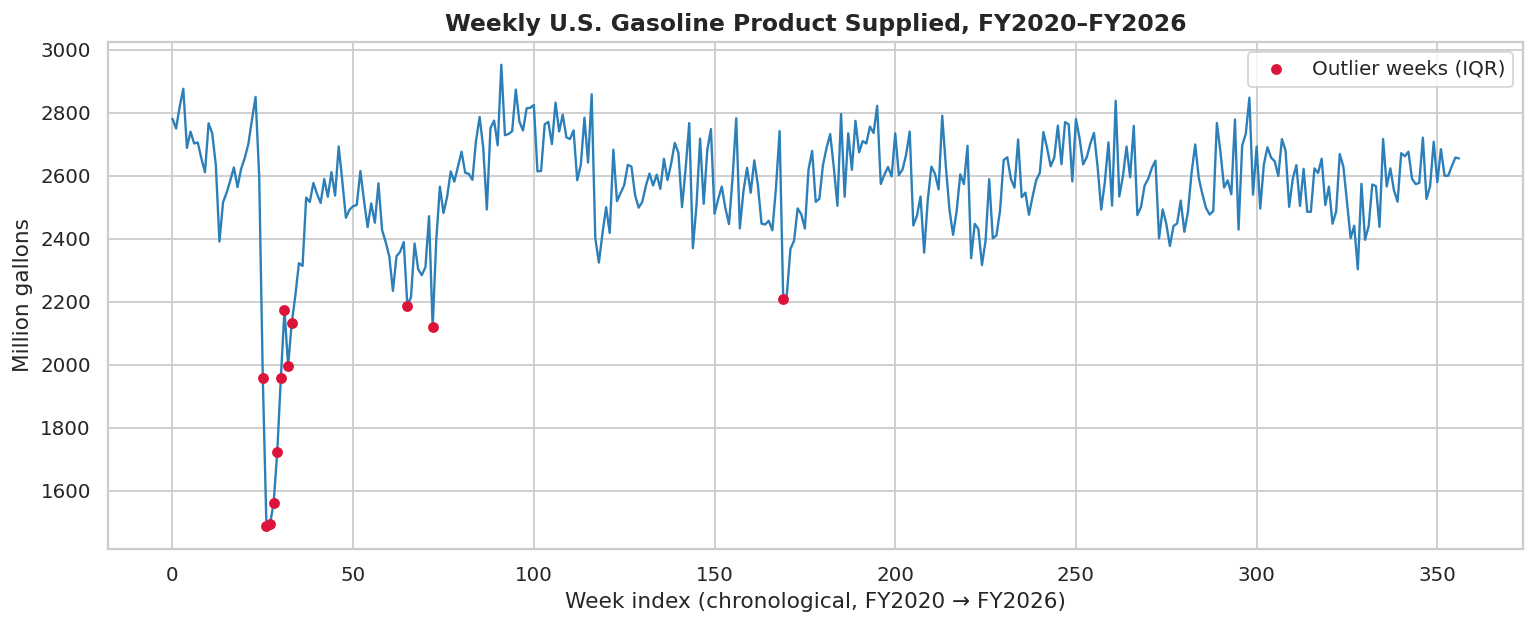

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["current_year_million_gal"], color="#2c7fb8", linewidth=1.3)
covid_idx = df.index[df["is_outlier"]]
plt.scatter(covid_idx, df.loc[covid_idx, "current_year_million_gal"],
            color="crimson", zorder=5, s=25, label="Outlier weeks (IQR)")
plt.title("Weekly U.S. Gasoline Product Supplied, FY2020–FY2026")
plt.xlabel("Week index (chronological, FY2020 → FY2026)")
plt.ylabel("Million gallons")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 — Seasonal overlay: production by fiscal week, one line per year
Plotting every fiscal year on the same week axis reveals the *seasonal shape*
(low in winter, rising into a summer "driving season" peak) and lets years be
compared directly, including how far below prior years FY2020 fell.

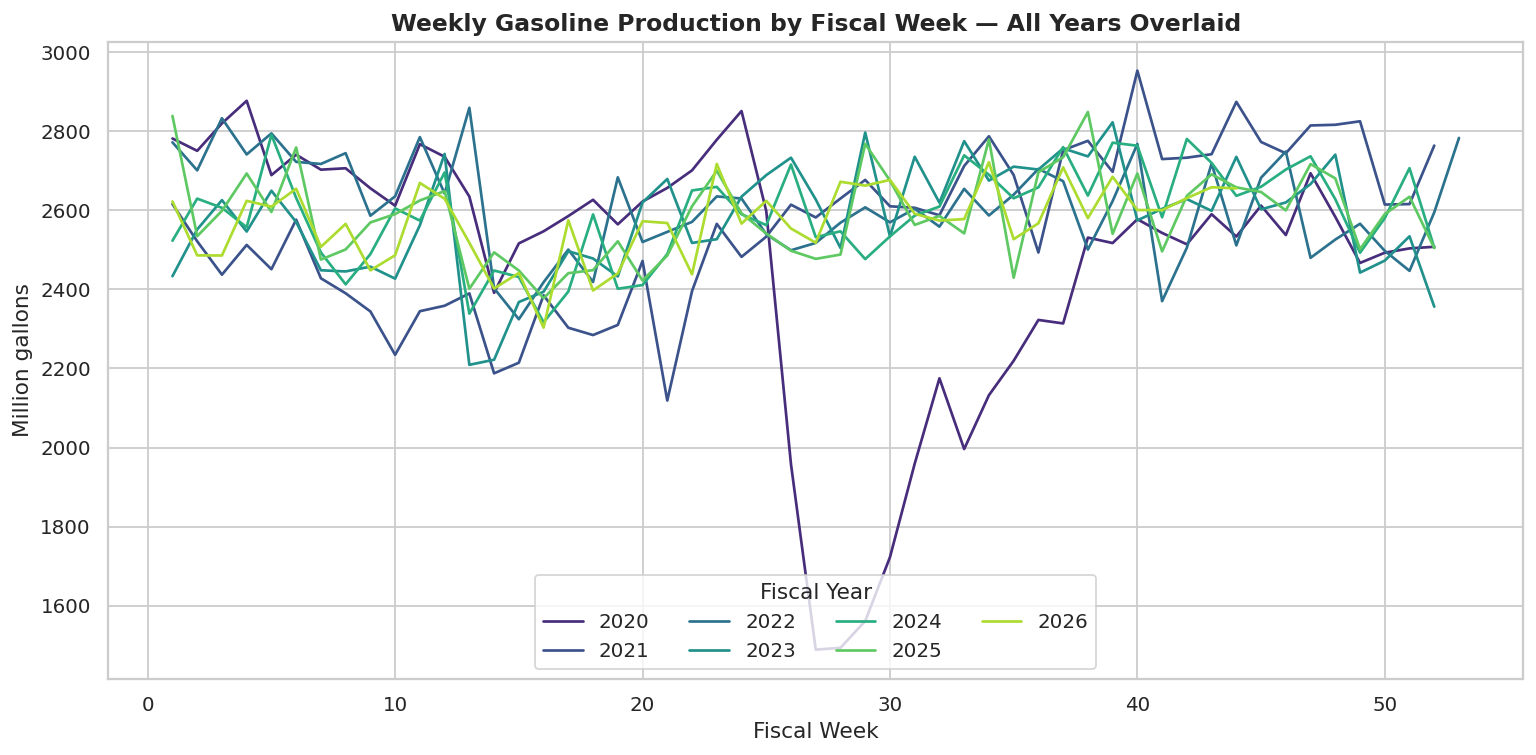

In [19]:
plt.figure(figsize=(12, 6))
palette = sns.color_palette("viridis", n_colors=df["fiscal_year"].nunique())
for color, (yr, grp) in zip(palette, df.groupby("fiscal_year")):
    grp = grp.sort_values("fiscal_week")
    plt.plot(grp["fiscal_week"], grp["current_year_million_gal"], label=str(yr), color=color)
plt.title("Weekly Gasoline Production by Fiscal Week — All Years Overlaid")
plt.xlabel("Fiscal Week")
plt.ylabel("Million gallons")
plt.legend(title="Fiscal Year", ncol=4, loc="lower center")
plt.tight_layout()
plt.show()

### 5.3 — Total production by fiscal year (bar chart)
FY2026 is still in progress (through week 44 only), so its bar is naturally
shorter — it is annotated rather than compared directly to completed years.

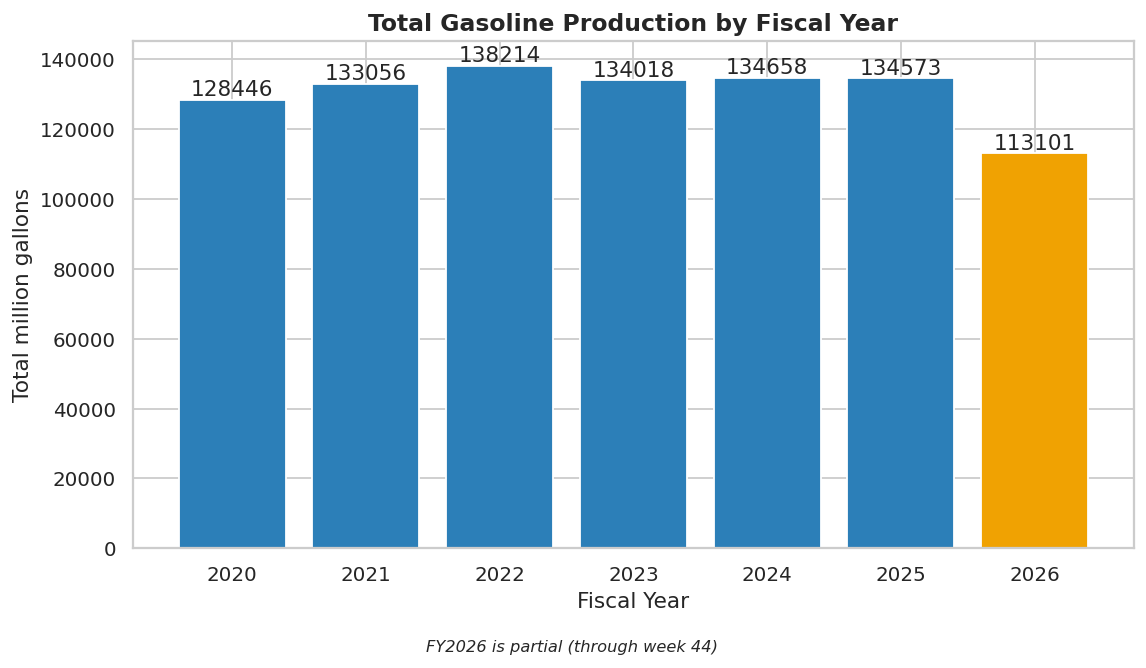

In [21]:
annual_totals = df.groupby("fiscal_year")["current_year_million_gal"].sum()
colors = ["#f0a202" if yr == latest_year else "#2c7fb8" for yr in annual_totals.index]

plt.figure(figsize=(9, 5))
bars = plt.bar(annual_totals.index.astype(str), annual_totals.values, color=colors)
plt.title("Total Gasoline Production by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Total million gallons")
plt.bar_label(bars, fmt="%.0f")
plt.figtext(0.5, -0.02, f"FY{latest_year} is partial (through week {int(df.loc[df.fiscal_year==latest_year,'fiscal_week'].max())})",
            ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

### 5.4 — Average weekly production by fiscal year
Dividing by number of weeks removes the partial-year distortion from FY2026 and
gives a fair year-over-year comparison of typical demand levels.

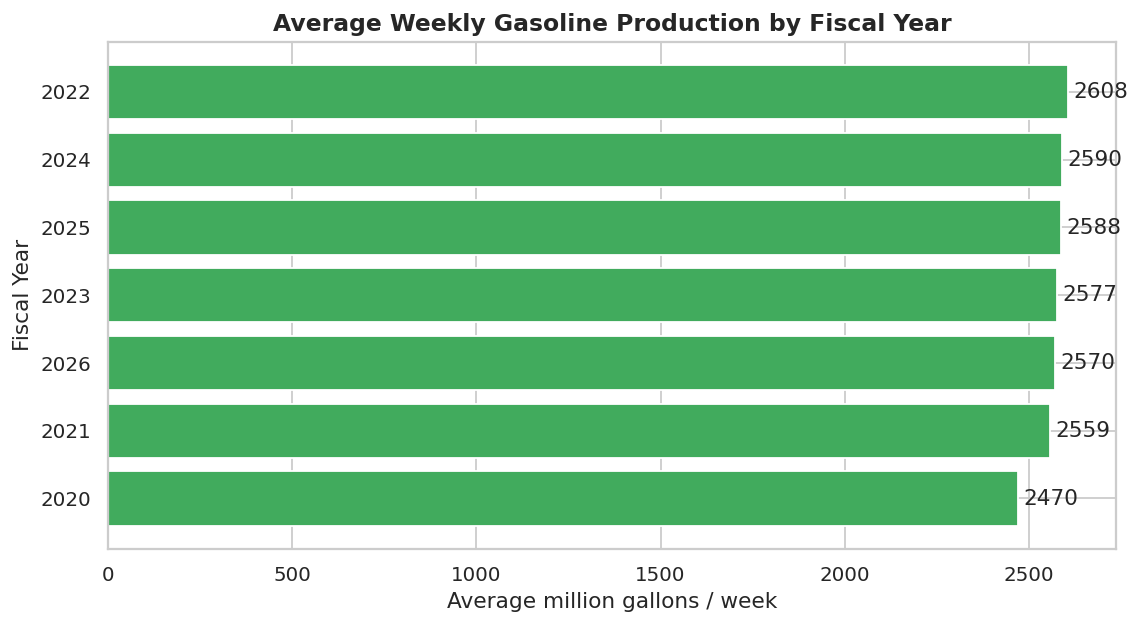

In [23]:
annual_avg = df.groupby("fiscal_year")["current_year_million_gal"].mean().sort_values()

plt.figure(figsize=(9, 5))
bars = plt.barh(annual_avg.index.astype(str), annual_avg.values, color="#41ab5d")
plt.title("Average Weekly Gasoline Production by Fiscal Year")
plt.xlabel("Average million gallons / week")
plt.ylabel("Fiscal Year")
plt.bar_label(bars, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

### 5.5 — Distribution of weekly production by fiscal year (boxplot)
Shows the spread and any outliers within each year side-by-side. FY2020's box
sits noticeably lower and wider — a direct visual signature of pandemic volatility.

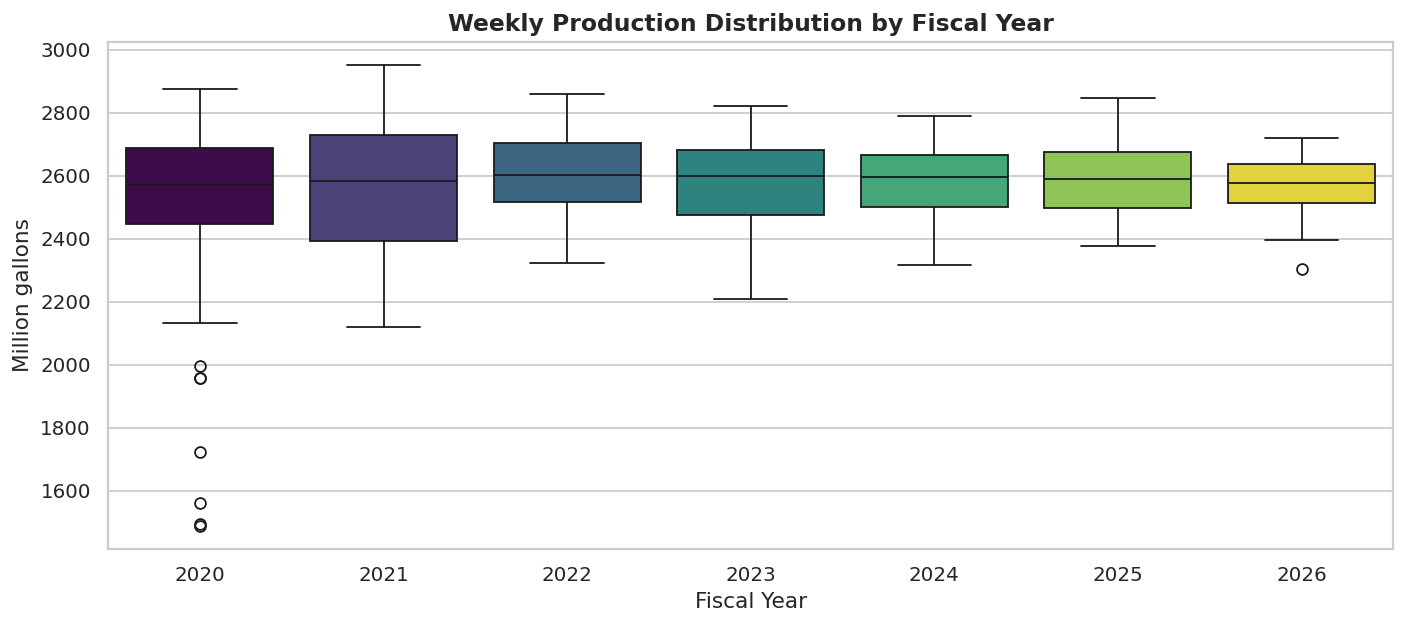

In [25]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="fiscal_year", y="current_year_million_gal",
            hue="fiscal_year", palette="viridis", legend=False)
plt.title("Weekly Production Distribution by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Million gallons")
plt.tight_layout()
plt.show()

### 5.6 — Category-wise analysis: production by fiscal quarter
Q1 (Oct–Dec) and Q2 (Jan–Mar) sit lower; Q3 (Apr–Jun) and Q4 (Jul–Sep) run higher,
consistent with the U.S. summer driving season.

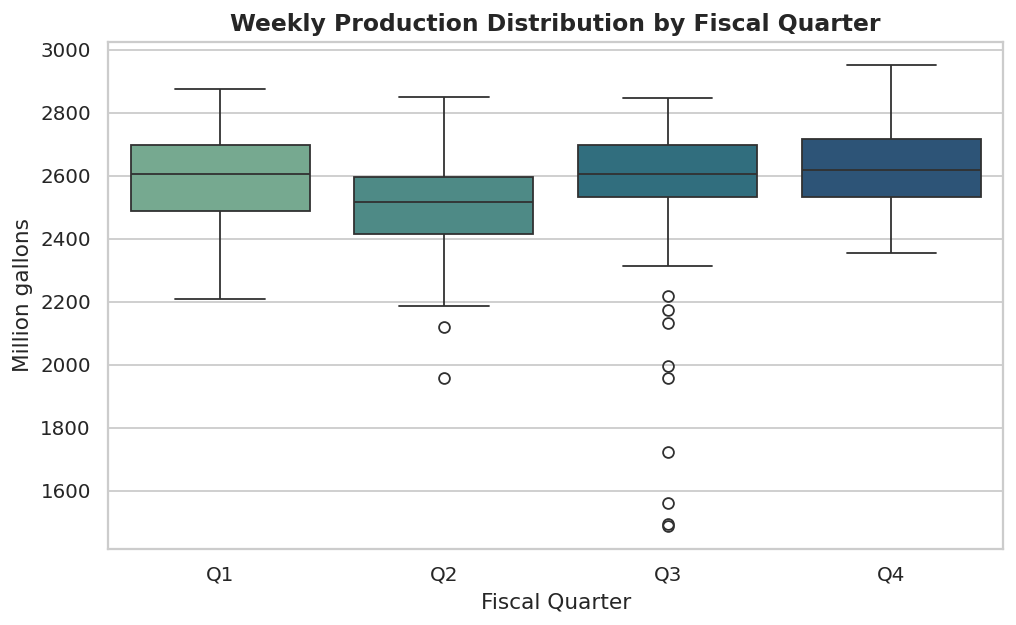

In [27]:
plt.figure(figsize=(8, 5))
order = ["Q1", "Q2", "Q3", "Q4"]
sns.boxplot(data=df, x="fiscal_quarter", y="current_year_million_gal", order=order,
            hue="fiscal_quarter", palette="crest", legend=False)
plt.title("Weekly Production Distribution by Fiscal Quarter")
plt.xlabel("Fiscal Quarter")
plt.ylabel("Million gallons")
plt.tight_layout()
plt.show()

### 5.7 — Histogram: distribution of weekly production volumes

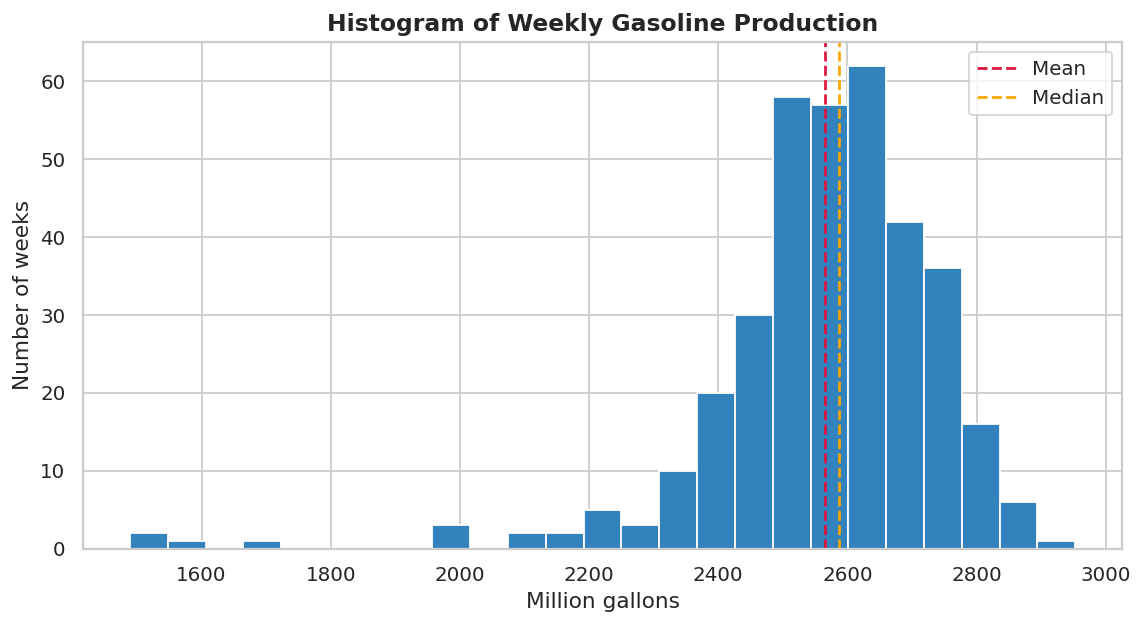

In [29]:
plt.figure(figsize=(9, 5))
plt.hist(df["current_year_million_gal"], bins=25, color="#3182bd", edgecolor="white")
plt.axvline(df["current_year_million_gal"].mean(), color="crimson", linestyle="--", label="Mean")
plt.axvline(df["current_year_million_gal"].median(), color="orange", linestyle="--", label="Median")
plt.title("Histogram of Weekly Gasoline Production")
plt.xlabel("Million gallons")
plt.ylabel("Number of weeks")
plt.legend()
plt.tight_layout()
plt.show()

### 5.8 — Distribution plot (KDE) split by outlier status

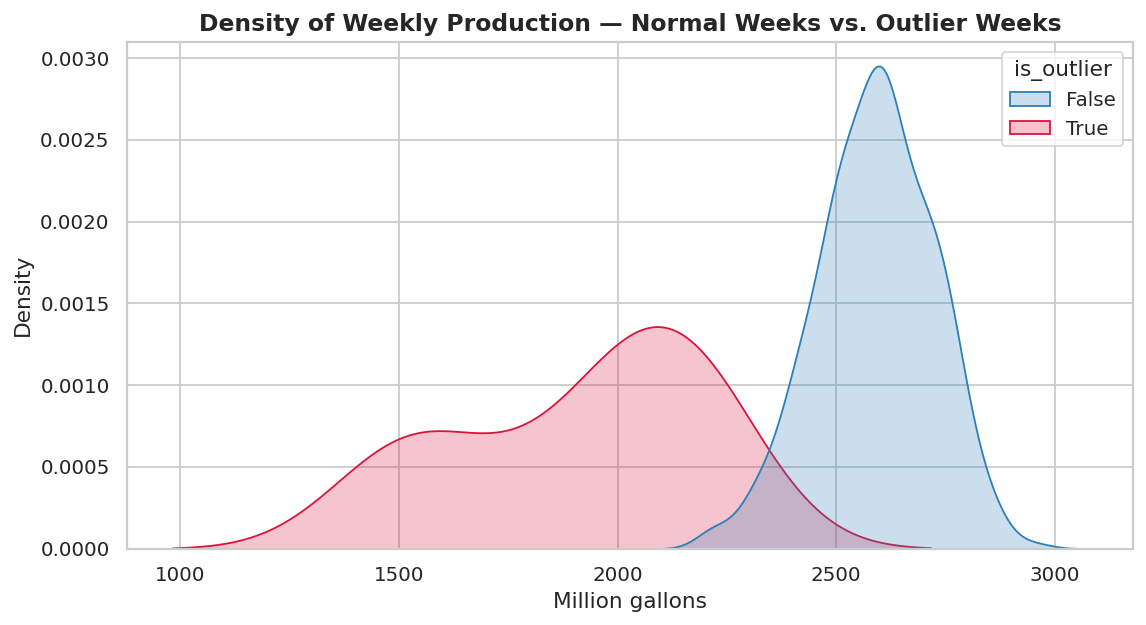

In [31]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="current_year_million_gal", hue="is_outlier", fill=True,
            common_norm=False, palette={True: "crimson", False: "#2c7fb8"})
plt.title("Density of Weekly Production — Normal Weeks vs. Outlier Weeks")
plt.xlabel("Million gallons")
plt.tight_layout()
plt.show()

### 5.9 — Correlation heatmap
Raw weekly current-year and previous-year production turn out to be only weakly
correlated — week-to-week idiosyncratic swings are large relative to the smooth
seasonal signal at this granularity. The **cumulative** current-year and
previous-year totals, by contrast, are almost perfectly correlated, since both
are running sums that climb together through the fiscal year — this is why the
DOT/EIA source reports track *cumulative* pace rather than comparing single
weeks directly.

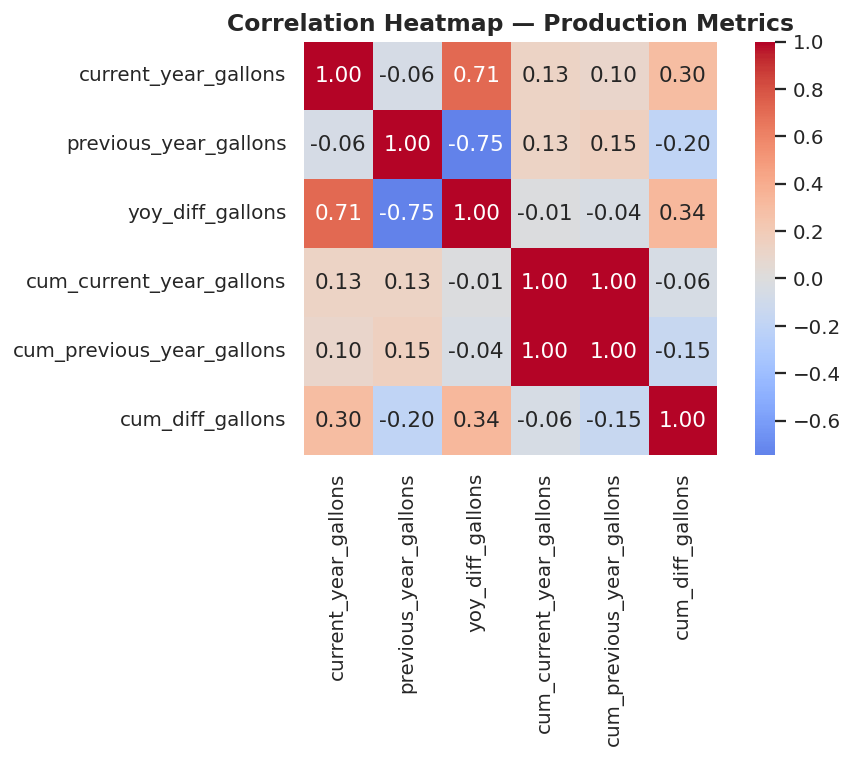

In [33]:
corr_cols = ["current_year_gallons", "previous_year_gallons", "yoy_diff_gallons",
             "cum_current_year_gallons", "cum_previous_year_gallons", "cum_diff_gallons"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Production Metrics")
plt.tight_layout()
plt.show()

### 5.10 — Scatter plot: current-year vs. previous-year weekly production
The points form a fairly diffuse cloud rather than hugging the diagonal — confirming
that a single week's production is not a reliable predictor of the same week one
year earlier. The outlier (red) points sit well below the main cloud on the
current-year axis: these are the COVID-affected FY2020 weeks, where current-year
production fell far short of the comparable prior-year week.

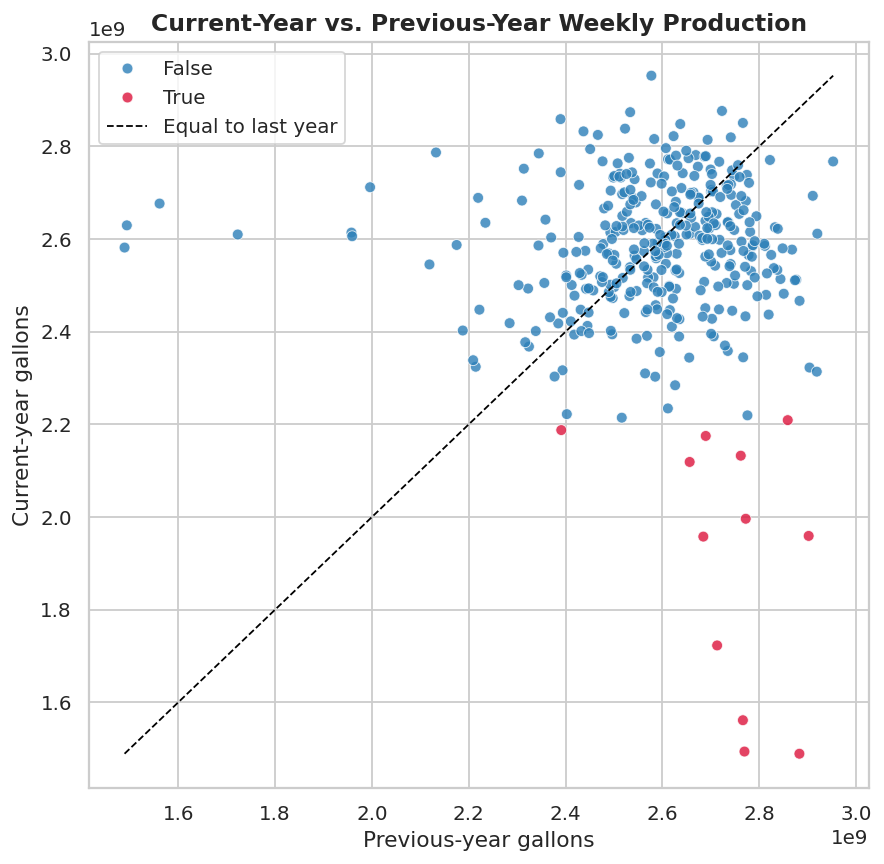

In [35]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x="previous_year_gallons", y="current_year_gallons",
                 hue="is_outlier", palette={True: "crimson", False: "#2c7fb8"}, alpha=0.8)
lims = [df[["previous_year_gallons","current_year_gallons"]].min().min(),
        df[["previous_year_gallons","current_year_gallons"]].max().max()]
plt.plot(lims, lims, "k--", linewidth=1, label="Equal to last year")
plt.title("Current-Year vs. Previous-Year Weekly Production")
plt.xlabel("Previous-year gallons")
plt.ylabel("Current-year gallons")
plt.legend()
plt.tight_layout()
plt.show()

### 5.11 — Trend analysis: raw weekly values vs. 4-week rolling average
The rolling average smooths weekly noise so the underlying seasonal trend and
the pandemic-era dip stand out clearly.

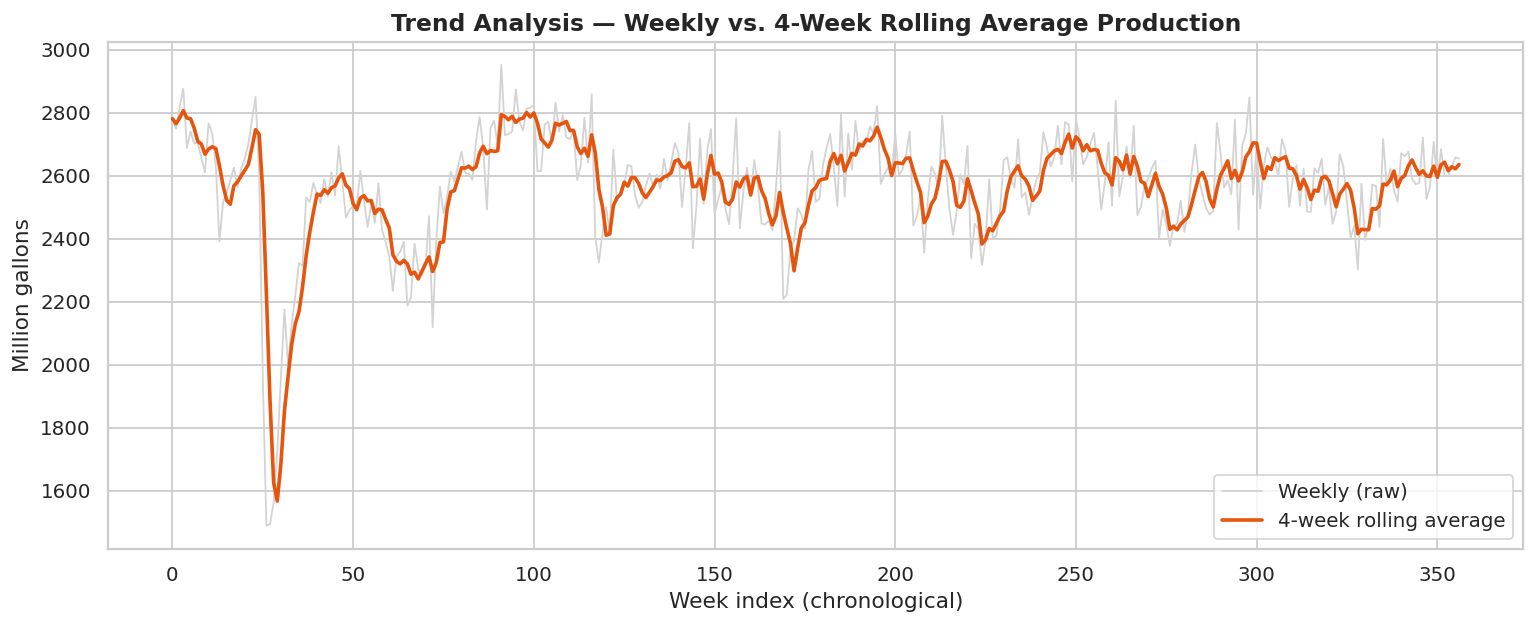

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["current_year_million_gal"], color="lightgray", linewidth=1, label="Weekly (raw)")
plt.plot(df.index, df["roll4_million_gal"], color="#e6550d", linewidth=2, label="4-week rolling average")
plt.title("Trend Analysis — Weekly vs. 4-Week Rolling Average Production")
plt.xlabel("Week index (chronological)")
plt.ylabel("Million gallons")
plt.legend()
plt.tight_layout()
plt.show()

### 5.12 — Top-performing weeks and quarters
The 10 highest-volume weeks on record, and the average output by quarter,
identifying which periods drive the most demand.

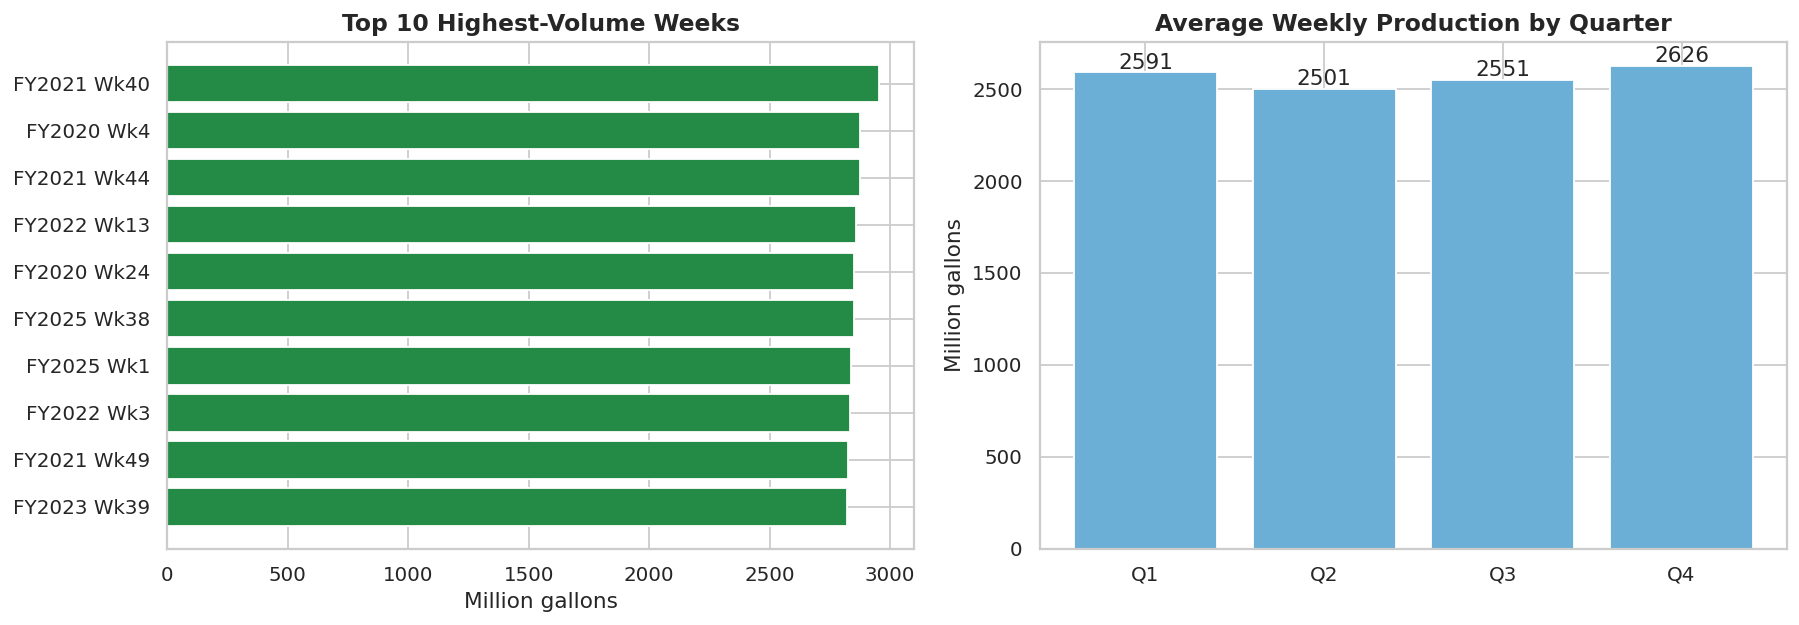

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = df.nlargest(10, "current_year_million_gal").copy()
top10["label"] = "FY" + top10["fiscal_year"].astype(str) + " Wk" + top10["fiscal_week"].astype(str)
axes[0].barh(top10["label"][::-1], top10["current_year_million_gal"][::-1], color="#238b45")
axes[0].set_title("Top 10 Highest-Volume Weeks")
axes[0].set_xlabel("Million gallons")

quarter_avg = df.groupby("fiscal_quarter")["current_year_million_gal"].mean().reindex(["Q1","Q2","Q3","Q4"])
bars = axes[1].bar(quarter_avg.index, quarter_avg.values, color="#6baed6")
axes[1].set_title("Average Weekly Production by Quarter")
axes[1].set_ylabel("Million gallons")
axes[1].bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

### 5.13 — Cumulative production gap: FY2026 vs. FY2025
Mirrors the source agency's own reporting style: running cumulative totals for
the current (partial) fiscal year against the same weeks last year, showing
whether the current year is ahead of or behind the prior year's pace.

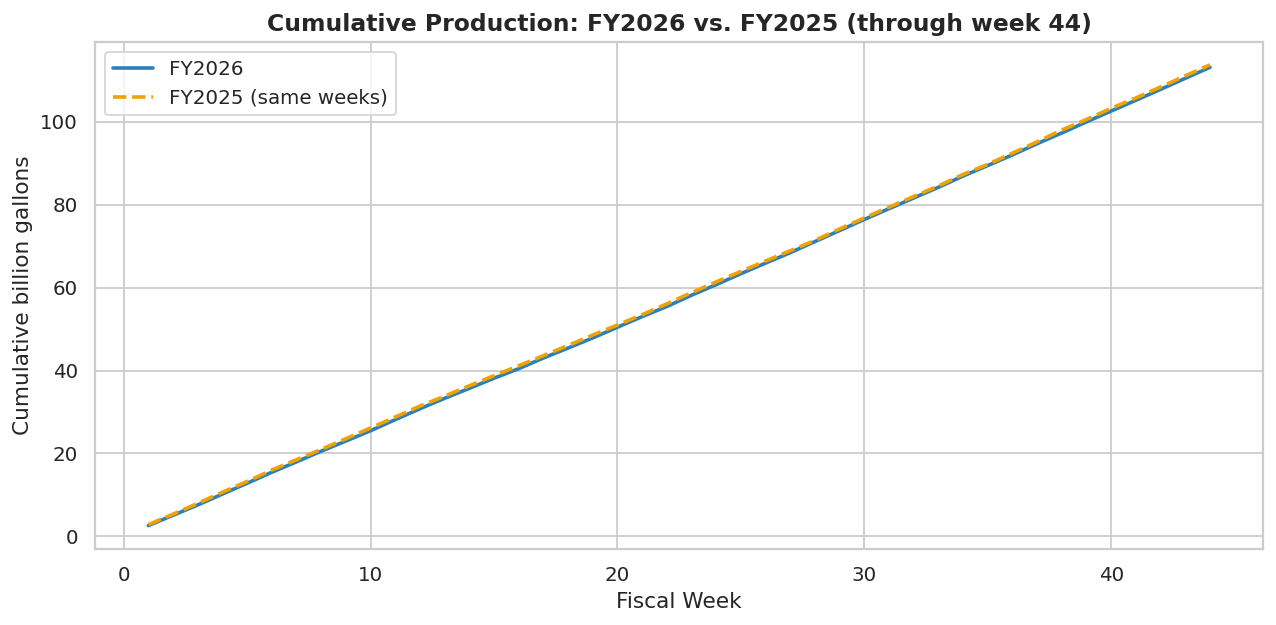

In [41]:
latest = df[df.fiscal_year == latest_year].sort_values("fiscal_week")
prior  = df[df.fiscal_year == latest_year - 1].sort_values("fiscal_week")
prior_through = prior[prior.fiscal_week <= latest.fiscal_week.max()]

plt.figure(figsize=(10, 5))
plt.plot(latest["fiscal_week"], latest["cum_current_year_gallons"] / 1e9, label=f"FY{latest_year}", color="#2c7fb8", linewidth=2)
plt.plot(prior_through["fiscal_week"], prior_through["current_year_gallons"].cumsum() / 1e9,
         label=f"FY{latest_year-1} (same weeks)", color="#f0a202", linewidth=2, linestyle="--")
plt.title(f"Cumulative Production: FY{latest_year} vs. FY{latest_year-1} (through week {int(latest.fiscal_week.max())})")
plt.xlabel("Fiscal Week")
plt.ylabel("Cumulative billion gallons")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Summary of Insights

In [43]:
overall_avg = df["current_year_million_gal"].mean()
best_year = annual_avg.idxmax()
worst_year = annual_avg.idxmin()
best_quarter = quarter_avg.idxmax()
covid_drop_pct = (df.loc[df.is_outlier, "yoy_diff_gallons"].min()) / \
                 df.loc[df.is_outlier, "previous_year_gallons"].max() * 100
weekly_corr = corr.loc["current_year_gallons", "previous_year_gallons"]
cum_corr = corr.loc["cum_current_year_gallons", "cum_previous_year_gallons"]
latest_gap_bn = (latest["cum_current_year_gallons"].iloc[-1] - prior_through["current_year_gallons"].cumsum().iloc[-1]) / 1e9

print(f"- Average weekly production across FY2020-FY{latest_year}: {overall_avg:,.0f} million gallons")
print(f"- Highest average weekly output: FY{best_year} ({annual_avg[best_year]:,.0f} M gal/week)")
print(f"- Lowest average weekly output: FY{worst_year} ({annual_avg[worst_year]:,.0f} M gal/week) — the COVID-19 year")
print(f"- Strongest quarter for demand: {best_quarter} (avg {quarter_avg[best_quarter]:,.0f} M gal/week)")
print(f"- {len(outliers)} weeks flagged as statistical outliers, all within FY2020 (COVID-19 demand shock)")
print(f"- Raw weekly current-vs-previous-year correlation: {weekly_corr:.3f} (weak — week-level noise dominates)")
print(f"- Cumulative current-vs-previous-year correlation: {cum_corr:.3f} (near-perfect — cumulative tracking is far more reliable)")
print(f"- FY{latest_year} cumulative production is {'ahead of' if latest_gap_bn>0 else 'behind'} the FY{latest_year-1} pace "
      f"by {abs(latest_gap_bn):,.2f} billion gallons through week {int(latest.fiscal_week.max())}")

- Average weekly production across FY2020-FY2026: 2,566 million gallons
- Highest average weekly output: FY2022 (2,608 M gal/week)
- Lowest average weekly output: FY2020 (2,470 M gal/week) — the COVID-19 year
- Strongest quarter for demand: Q4 (avg 2,626 M gal/week)
- 12 weeks flagged as statistical outliers, all within FY2020 (COVID-19 demand shock)
- Raw weekly current-vs-previous-year correlation: -0.062 (weak — week-level noise dominates)
- Cumulative current-vs-previous-year correlation: 0.996 (near-perfect — cumulative tracking is far more reliable)
- FY2026 cumulative production is behind the FY2025 pace by 0.60 billion gallons through week 44


**Narrative summary:**
Weekly U.S. gasoline supply follows a repeating seasonal pattern — lower in
fiscal Q1/Q2 (fall/winter) and higher in Q3/Q4 (spring/summer driving season) —
but that pattern is only visible after averaging: at the raw single-week level,
current-year and previous-year volumes are weakly correlated, since ordinary
week-to-week noise (holiday timing, refinery outages, reporting quirks) is large
relative to the smooth seasonal swing. Once values are accumulated over the
fiscal year, that noise cancels out and current-vs-previous-year cumulative
totals become almost perfectly correlated — which is exactly why the source
agency (and this notebook) tracks *cumulative* pace rather than comparing single
weeks. The one major break from the normal pattern is FY2020, where gasoline
demand collapsed for several consecutive weeks during the early COVID-19
lockdowns, visible both as a cluster of IQR outliers and as the year with the
lowest average weekly output on record. Every other year has stayed in a broadly
similar seasonal range, and the current fiscal year's cumulative total can be
tracked in real time against the prior year's pace using the same-week
cumulative comparison.

## 7. Challenges Faced and Solutions

| Challenge | Solution |
|---|---|
| Numeric columns were stored as quoted text with thousands-separator commas, and some negative numbers had a stray leading apostrophe (an Excel "force text" artifact) | Wrote a `clean_number()` function to strip the apostrophe and commas before casting to `float` |
| FY2022 week 53 (a 53rd "leap" fiscal week) had no comparable prior-year week, recorded as `Previous Year Production = 0` / `Difference = N/A` | Treated `0` as not-applicable and set both fields to `NaN` rather than treating it as a real zero-production week |
| FY2025 week 11 was missing entirely (not just null — the whole row was absent) | Recovered the exact value from the untouched running-cumulative column (`cum(wk12) − cum(wk10) − production(wk12)`) instead of estimating it with interpolation |
| A cluster of unusually low weeks in FY2020 initially looked like data-entry errors | Investigated the dates (March–April 2020) and confirmed via IQR outlier detection that they reflect a real event (COVID-19 demand collapse) — flagged with `is_outlier` and kept rather than removed |
| No natural categorical column existed for category-wise analysis | Engineered a `fiscal_quarter` feature from the week number and one-hot encoded it for further analysis |